# Desafio - Fine-tuning de um ViT para classificação de imagens

Este notebook resolve o desafio:

> **Como usar um ViT (Visual Transformer) para realizar fine-tuning e criar um classificador para uma base de imagens com 10 classes?**

A estratégia escolhida foi **PyTorch + Hugging Face Transformers**, porque essa combinação costuma ser mais simples e estável para fine-tuning de modelos ViT em Colab do que a versão TensorFlow/Keras.

## Conceito

O **Vision Transformer (ViT)** adapta a arquitetura Transformer para imagens. Em vez de tratar a entrada como uma sequência de palavras, o ViT divide a imagem em pequenos **patches**. Cada patch é transformado em um vetor, de forma semelhante a um token em NLP.

Para uma imagem de tamanho 224 × 224 e patches de 16 × 16, o número de patches é:

\[
N = \frac{224}{16} \times \frac{224}{16} = 14 \times 14 = 196
\]

Esses 196 patches são processados pelo Transformer. No final, uma cabeça de classificação é ajustada para prever uma das classes da base.

Como a base possui aproximadamente 1000 imagens e 10 classes, a estratégia mais adequada é **fine-tuning** a partir de um modelo pré-treinado, e não treinamento do zero.

## Fórmulas principais

### Número de patches

\[
N = \frac{H}{P} \times \frac{W}{P}
\]

Onde:

- \(H\) = altura da imagem;
- \(W\) = largura da imagem;
- \(P\) = tamanho do patch.

### Função de perda para classificação multiclasse

Como o problema possui 10 classes, usamos **Cross-Entropy Loss**:

\[
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
\]

Onde:

- \(C\) é o número de classes;
- \(y_i\) é o rótulo real codificado em one-hot;
- \(\hat{y}_i\) é a probabilidade predita para a classe \(i\).

### Métricas de avaliação

Além da acurácia, serão avaliados:

- **precision** por classe;
- **recall** por classe;
- **F1-score** por classe;
- **F1 macro**, importante quando há desequilíbrio entre classes;
- matriz de confusão.

# 1. Instalação e imports

In [ ]:
!pip install -q "transformers==4.44.2" scikit-learn matplotlib pandas "pillow<12" gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.1 MB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from torchvision.datasets import ImageFolder
from torchvision import transforms

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import AutoImageProcessor, AutoModelForImageClassification

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA disponível: True
GPU: Tesla T4


# 2. Acesso à base no Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = Path('/content/drive/MyDrive/Base')

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def count_images_in_folder(folder: Path):
    return sum(1 for f in folder.rglob("*") if f.suffix.lower() in IMAGE_EXTENSIONS)

def find_imagefolder_root(base_dir: Path, min_classes=2):
    candidates = []
    search_dirs = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]

    for p in search_dirs:
        subdirs = [d for d in p.iterdir() if d.is_dir()]

        if len(subdirs) < min_classes:
            continue

        class_counts = {d.name: count_images_in_folder(d) for d in subdirs}
        valid_counts = {k: v for k, v in class_counts.items() if v > 0}

        if len(valid_counts) >= min_classes:
            total = sum(valid_counts.values())
            candidates.append((p, total, len(valid_counts), valid_counts))

    if not candidates:
        raise FileNotFoundError(
            "Não encontrei uma pasta no formato ImageFolder. "
            "Verifique se a base está organizada como dataset/classe/imagem.jpg."
        )

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    return candidates[0]

print("DATA_DIR:", DATA_DIR)
print("Existe?", DATA_DIR.exists())

DATA_DIR: /content/drive/MyDrive/Base
Existe? True


In [ ]:
DATA_ROOT, total_images, n_classes_found, class_counts = find_imagefolder_root(DATA_DIR)

print("Pasta raiz detectada:", DATA_ROOT)
print("Total de imagens:", total_images)
print("Número de classes detectadas:", n_classes_found)
print("Distribuição por classe:")

for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count}")

Pasta raiz detectada: /content/drive/MyDrive/Base
Total de imagens: 1000
Número de classes detectadas: 10
Distribuição por classe:
cavalos: 100
comida: 100
dino: 100
elefante: 100
flores: 100
humanos: 100
montanhas: 100
obras: 100
onibus: 100
praia: 100


# 3. Carregar a base com ImageFolder e inspecionar classes

O `ImageFolder` interpreta cada subpasta como uma classe e atribui um índice numérico para cada classe.

In [ ]:
base_dataset = ImageFolder(root=str(DATA_ROOT))

class_names = base_dataset.classes
class_to_idx = base_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Classes:")
for i, cls in enumerate(class_names):
    print(i, "->", cls)

print("\nTotal de imagens:", len(base_dataset))

Classes:
0 -> cavalos
1 -> comida
2 -> dino
3 -> elefante
4 -> flores
5 -> humanos
6 -> montanhas
7 -> obras
8 -> onibus
9 -> praia

Total de imagens: 1000


In [ ]:
# Distribuição das classes
labels = [label for _, label in base_dataset.samples]
counts = pd.Series(labels).map(idx_to_class).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "classe": counts.index,
    "quantidade": counts.values,
    "proporcao": counts.values / counts.values.sum()
})

class_distribution

,classe,quantidade,proporcao
0,cavalos,100,0.1
1,comida,100,0.1
2,dino,100,0.1
3,elefante,100,0.1
4,flores,100,0.1
5,humanos,100,0.1
6,montanhas,100,0.1
7,obras,100,0.1
8,onibus,100,0.1
9,praia,100,0.1


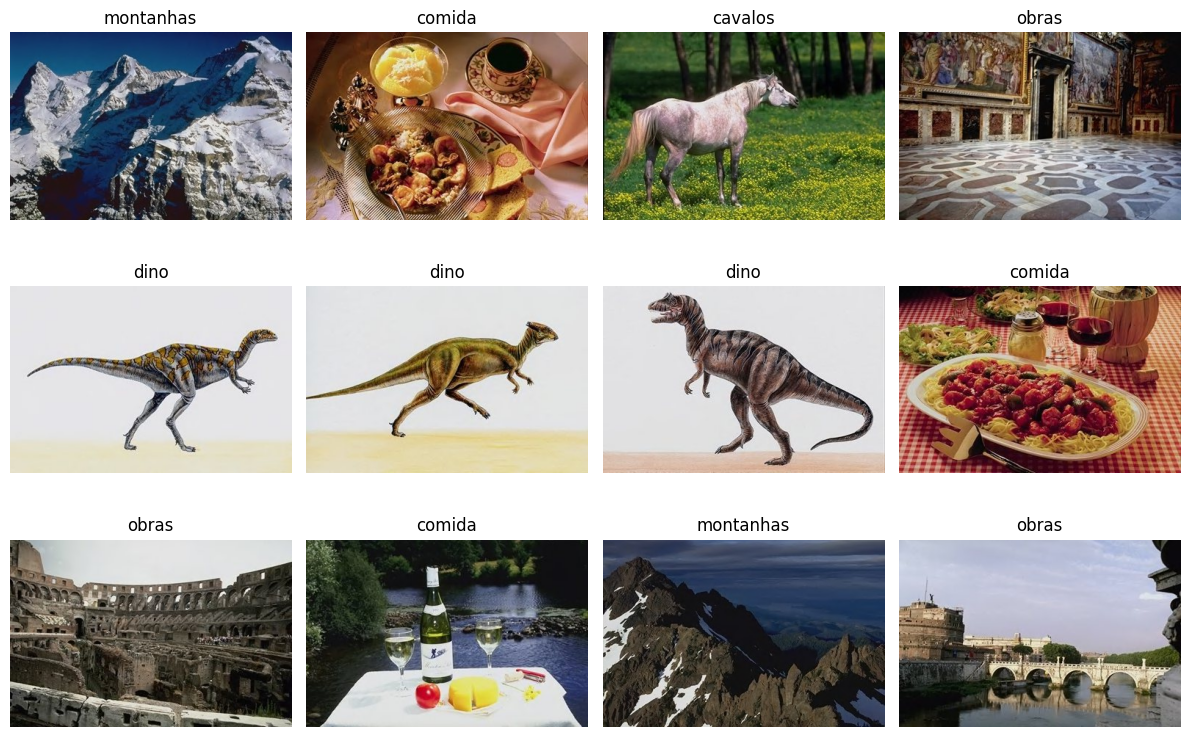

In [ ]:
# Visualizar algumas imagens aleatórias
n_samples = min(12, len(base_dataset))
indices = random.sample(range(len(base_dataset)), n_samples)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices):
    img, label = base_dataset[idx]
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(idx_to_class[label])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Divisão treino / validação / teste

Será usada divisão estratificada:

- **70% treino**
- **15% validação**
- **15% teste**

A estratificação mantém a proporção das classes em cada subconjunto.

In [ ]:
samples = base_dataset.samples
paths = [p for p, y in samples]
y = [label for p, label in samples]

# Primeiro: separa treino de temporário, mantendo 30% para validação + teste
train_samples, temp_samples, y_train, y_temp = train_test_split(
    samples,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Segundo: divide o temporário ao meio: 15% validação, 15% teste
val_samples, test_samples, y_val, y_test = train_test_split(
    temp_samples,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Treino:", len(train_samples))
print("Validação:", len(val_samples))
print("Teste:", len(test_samples))

Treino: 700
Validação: 150
Teste: 150


In [ ]:
def distribution_from_samples(samples, name):
    labels = [label for _, label in samples]
    counts = pd.Series(labels).map(idx_to_class).value_counts().sort_index()
    return pd.DataFrame({
        "conjunto": name,
        "classe": counts.index,
        "quantidade": counts.values,
        "proporcao": counts.values / counts.values.sum()
    })

pd.concat([
    distribution_from_samples(train_samples, "treino"),
    distribution_from_samples(val_samples, "validacao"),
    distribution_from_samples(test_samples, "teste")
], ignore_index=True)

,conjunto,classe,quantidade,proporcao
0,treino,cavalos,70,0.1
1,treino,comida,70,0.1
2,treino,dino,70,0.1
3,treino,elefante,70,0.1
4,treino,flores,70,0.1
5,treino,humanos,70,0.1
6,treino,montanhas,70,0.1
7,treino,obras,70,0.1
8,treino,onibus,70,0.1
9,treino,praia,70,0.1


# 5. Preparar o ViT e o dataset PyTorch

Modelo usado:

```text
google/vit-base-patch16-224-in21k
```

Esse checkpoint é adequado para fine-tuning porque já foi pré-treinado em uma grande base de imagens. A cabeça de classificação será substituída para o número de classes da nossa base.

In [ ]:
MODEL_CHECKPOINT = "google/vit-base-patch16-224-in21k"

image_processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)

id2label = {i: cls for i, cls in enumerate(class_names)}
label2id = {cls: i for i, cls in enumerate(class_names)}

model = AutoModelForImageClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(class_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Número de classes:", len(class_names))
print("Modelo carregado:", MODEL_CHECKPOINT)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Número de classes: 10
Modelo carregado: google/vit-base-patch16-224-in21k


In [ ]:
class ViTImageDataset(Dataset):
    def __init__(self, samples, image_processor, augment=False):
        self.samples = samples
        self.image_processor = image_processor
        self.augment = augment

        self.train_augment = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.80, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        if self.augment:
            image = self.train_augment(image)

        encoding = self.image_processor(images=image, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze(0)

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(label, dtype=torch.long)
        }

train_dataset = ViTImageDataset(train_samples, image_processor, augment=True)
val_dataset = ViTImageDataset(val_samples, image_processor, augment=False)
test_dataset = ViTImageDataset(test_samples, image_processor, augment=False)

print("Dataset de treino:", len(train_dataset))
print("Dataset de validação:", len(val_dataset))
print("Dataset de teste:", len(test_dataset))

Dataset de treino: 700
Dataset de validação: 150
Dataset de teste: 150


In [ ]:
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["labels"].item() for item in batch], dtype=torch.long)
    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

# Teste rápido de um batch
batch = collate_fn([train_dataset[i] for i in range(min(4, len(train_dataset)))])
print(batch["pixel_values"].shape)
print(batch["labels"])

torch.Size([4, 3, 224, 224])
tensor([8, 2, 1, 1])


# 6. DataLoaders e função de avaliação

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def avaliar_modelo(model, dataloader, return_outputs=False):
    model.eval()

    all_preds = []
    all_labels = []
    all_logits = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if return_outputs:
                all_logits.append(logits.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    resultados = {
        "loss": total_loss / len(dataloader),
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "y_true": all_labels,
        "y_pred": all_preds
    }

    if return_outputs:
        resultados["logits"] = np.concatenate(all_logits, axis=0)

    return resultados

print("DataLoaders criados.")
print("Treino:", len(train_loader), "batches")
print("Validação:", len(val_loader), "batches")
print("Teste:", len(test_loader), "batches")

DataLoaders criados.
Treino: 88 batches
Validação: 19 batches
Teste: 19 batches


# 7. Treinamento Manual

Para uma base pequena, o treinamento deve ser conservador (dica do professor Alceu ;)):

- poucas épocas;
- learning rate baixo;
- data augmentation leve;
- seleção do melhor modelo pelo F1 macro na validação.

3 épocas primeiro para validar tudo.

In [ ]:
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

best_f1_macro = -1
best_model_path = "/content/best_vit_model.pt"

historico = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in loop:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    train_loss = total_train_loss / len(train_loader)
    val_metrics = avaliar_modelo(model, val_loader)

    historico.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_f1_weighted": val_metrics["f1_weighted"]
    })

    print(f"\nEpoch {epoch + 1}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_metrics['loss']:.4f}")
    print(f"Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val F1 macro: {val_metrics['f1_macro']:.4f}")

    if val_metrics["f1_macro"] > best_f1_macro:
        best_f1_macro = val_metrics["f1_macro"]
        torch.save(model.state_dict(), best_model_path)
        print("Melhor modelo salvo.")

historico_df = pd.DataFrame(historico)
historico_df

Epoch 1/3:   0%|          | 0/88 [00:00<?, ?it/s]


Epoch 1
Train loss: 1.8430
Val loss: 1.3524
Val accuracy: 0.9667
Val F1 macro: 0.9664
Melhor modelo salvo.


Epoch 2/3:   0%|          | 0/88 [00:00<?, ?it/s]


Epoch 2
Train loss: 0.9737
Val loss: 0.7477
Val accuracy: 0.9733
Val F1 macro: 0.9731
Melhor modelo salvo.


Epoch 3/3:   0%|          | 0/88 [00:00<?, ?it/s]


Epoch 3
Train loss: 0.5529
Val loss: 0.5039
Val accuracy: 0.9800
Val F1 macro: 0.9798
Melhor modelo salvo.


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro,val_f1_weighted
0,1,1.842954,1.352448,0.966667,0.966407,0.966407
1,2,0.973741,0.747654,0.973333,0.973096,0.973096
2,3,0.552867,0.503901,0.980000,0.979763,0.979763


# 8. Avaliação no conjunto de teste

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

test_metrics = avaliar_modelo(model, test_loader, return_outputs=True)

print("Métricas no conjunto de teste:")
print("Accuracy:", test_metrics["accuracy"])
print("F1 macro:", test_metrics["f1_macro"])
print("F1 weighted:", test_metrics["f1_weighted"])
print("Precision macro:", test_metrics["precision_macro"])
print("Recall macro:", test_metrics["recall_macro"])

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]
logits = test_metrics["logits"]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

Métricas no conjunto de teste:
Accuracy: 0.9866666666666667
F1 macro: 0.9866518353726363
F1 weighted: 0.9866518353726363
Precision macro: 0.9875
Recall macro: 0.9866666666666667
              precision    recall  f1-score   support

     cavalos     1.0000    1.0000    1.0000        15
      comida     1.0000    1.0000    1.0000        15
        dino     1.0000    1.0000    1.0000        15
    elefante     1.0000    1.0000    1.0000        15
      flores     1.0000    1.0000    1.0000        15
     humanos     1.0000    0.9333    0.9655        15
   montanhas     1.0000    0.9333    0.9655        15
       obras     0.9375    1.0000    0.9677        15
      onibus     1.0000    1.0000    1.0000        15
       praia     0.9375    1.0000    0.9677        15

    accuracy                         0.9867       150
   macro avg     0.9875    0.9867    0.9867       150
weighted avg     0.9875    0.9867    0.9867       150



# 9. Matriz de confusão

A matriz de confusão mostra quais classes o modelo mais confunde entre si.

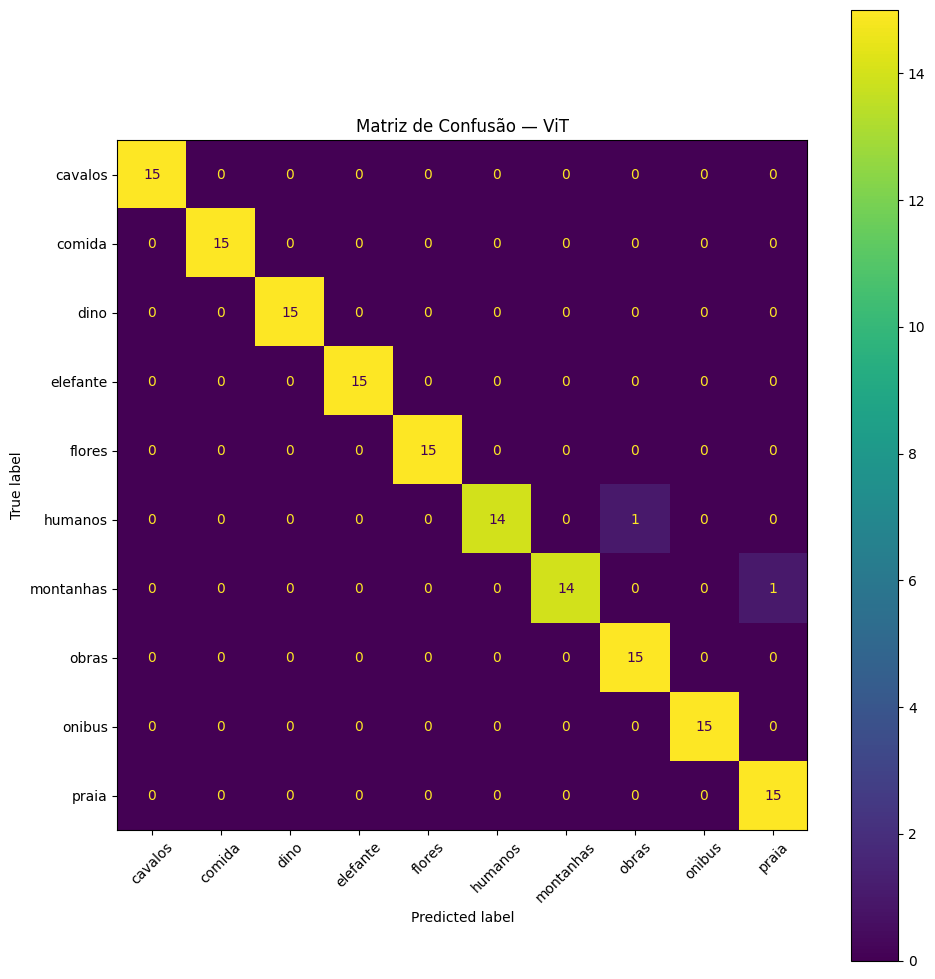

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Matriz de Confusão — ViT")
plt.tight_layout()
plt.show()

# 10. Exemplos classificados incorretamente

Esta etapa ajuda a responder se os erros do modelo fazem sentido visualmente. É importante verificar se há imagens ambíguas, baixa qualidade, objetos parecidos ou rótulos possivelmente inconsistentes.

In [ ]:
probs = torch.nn.functional.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

confidences = probs.max(axis=1)

error_rows = []

for (path, true_label), pred_label, conf in zip(test_samples, y_pred, confidences):
    error_rows.append({
        "arquivo": path,
        "classe_real": idx_to_class[true_label],
        "classe_predita": idx_to_class[pred_label],
        "correto": true_label == pred_label,
        "confianca": conf
    })

df_predicoes = pd.DataFrame(error_rows)
df_erros = df_predicoes[df_predicoes["correto"] == False].copy()

print("Total de exemplos de teste:", len(df_predicoes))
print("Total de erros:", len(df_erros))
print("Taxa de erro:", len(df_erros) / len(df_predicoes))

df_erros.sort_values("confianca", ascending=False).head(20)

Total de exemplos de teste: 150
Total de erros: 2
Taxa de erro: 0.013333333333333334


,arquivo,classe_real,classe_predita,correto,confianca
116,/content/drive/MyDrive/Base/montanhas/860.jpg,montanhas,praia,False,0.384692
62,/content/drive/MyDrive/Base/humanos/4.jpg,humanos,obras,False,0.315030


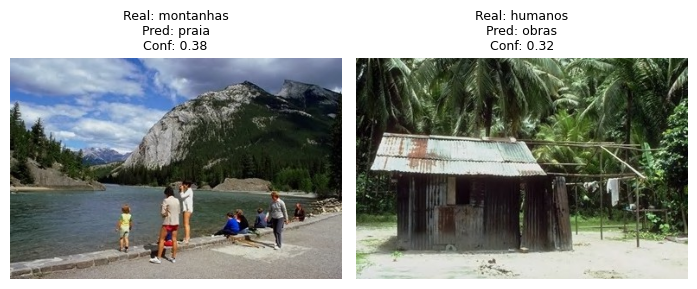

In [ ]:
def mostrar_erros(df_erros, n=12):
    if len(df_erros) == 0:
        print("Não houve erros no conjunto de teste.")
        return

    amostra = df_erros.sample(min(n, len(df_erros)), random_state=RANDOM_STATE)

    plt.figure(figsize=(14, 10))

    for i, (_, row) in enumerate(amostra.iterrows()):
        img = Image.open(row["arquivo"]).convert("RGB")

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(
            f"Real: {row['classe_real']}\nPred: {row['classe_predita']}\nConf: {row['confianca']:.2f}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_erros(df_erros, n=12)

O dataset é que está maluco. Eu concordo com o modelo. hahaha

# 11. Salvar o modelo treinado

Esta etapa salva o modelo e o processador de imagem para uso posterior.

In [ ]:
FINAL_MODEL_DIR = "/content/vit_modelo_final"

Path(FINAL_MODEL_DIR).mkdir(parents=True, exist_ok=True)

model.save_pretrained(FINAL_MODEL_DIR)
image_processor.save_pretrained(FINAL_MODEL_DIR)

print("Modelo salvo em:", FINAL_MODEL_DIR)

!zip -r /content/vit_modelo_final.zip /content/vit_modelo_final > /dev/null

print("Arquivo ZIP criado em: /content/vit_modelo_final.zip")

Modelo salvo em: /content/vit_modelo_final
Arquivo ZIP criado em: /content/vit_modelo_final.zip


## 12. Discussão dos resultados

O experimento realizou o **fine-tuning de um Vision Transformer (ViT)** para uma tarefa de **classificação multiclasse de imagens** com 10 classes: `cavalos`, `comida`, `dino`, `elefante`, `flores`, `humanos`, `montanhas`, `obras`, `onibus` e `praia`.

A base foi organizada no formato esperado pelo `ImageFolder`, em que cada subpasta representa uma classe. Foram identificadas **1000 imagens**, igualmente distribuídas entre as 10 classes, com **100 imagens por classe**. Portanto, a base está balanceada.

A divisão dos dados foi feita de forma estratificada em três conjuntos:

* **Treino:** 700 imagens, com 70 imagens por classe;
* **Validação:** 150 imagens, com 15 imagens por classe;
* **Teste:** 150 imagens, com 15 imagens por classe.

Essa divisão manteve a mesma proporção entre as classes em todos os subconjuntos, o que torna a avaliação mais justa.

O modelo utilizado foi o **`google/vit-base-patch16-224-in21k`**, um Vision Transformer pré-treinado em uma grande base de imagens. A cabeça final de classificação foi substituída por uma nova camada com **10 saídas**, correspondentes às classes da base utilizada neste desafio.

A estratégia adotada foi migrar para uma versão mais simples e estável em **PyTorch manual**, sem o uso do `Trainer` da Hugging Face. Essa decisão reduziu conflitos de dependência no Colab e permitiu controlar diretamente o treinamento, a avaliação e o salvamento do modelo.

Durante o treinamento, foram usados:

* `AutoImageProcessor` para pré-processamento das imagens;
* `AutoModelForImageClassification` para carregar o ViT pré-treinado;
* `AdamW` como otimizador;
* taxa de aprendizado de `2e-5`;
* `weight_decay=0.01`;
* batch size igual a 8;
* 3 épocas;
* data augmentation leve no treino, com `RandomResizedCrop`, `RandomHorizontalFlip` e `ColorJitter`.

Os resultados de validação melhoraram progressivamente ao longo das épocas:

| Época | Train loss | Val loss | Val accuracy | Val F1 macro |
| ----: | ---------: | -------: | -----------: | -----------: |
|     1 |     1.8430 |   1.3524 |       0.9667 |       0.9664 |
|     2 |     0.9737 |   0.7477 |       0.9733 |       0.9731 |
|     3 |     0.5529 |   0.5039 |       0.9800 |       0.9798 |

Observa-se que a perda de treino e a perda de validação diminuíram ao longo das três épocas, enquanto a acurácia e o F1 macro de validação aumentaram. Isso indica que, nesse intervalo de treinamento, não houve evidência clara de sobreajuste. A terceira época apresentou o melhor desempenho na validação e foi salva como o melhor modelo.

No conjunto de teste, o modelo obteve:

* **Acurácia:** 0.9867;
* **F1 macro:** 0.9867;
* **F1 ponderado:** 0.9867;
* **Precision macro:** 0.9875;
* **Recall macro:** 0.9867.

Como a base é perfeitamente balanceada, com 15 imagens por classe no conjunto de teste, o **F1 macro** e o **F1 ponderado** ficaram praticamente iguais. Isso reforça que o desempenho foi consistente entre as classes, sem favorecimento relevante de uma classe majoritária.

O relatório de classificação mostrou desempenho perfeito para as classes `cavalos`, `comida`, `dino`, `elefante`, `flores` e `onibus`, todas com precision, recall e F1-score iguais a 1.0000.

As únicas classes com pequenos erros foram:

* `humanos`: recall de 0.9333 e F1-score de 0.9655;
* `montanhas`: recall de 0.9333 e F1-score de 0.9655;
* `obras`: precision de 0.9375 e F1-score de 0.9677;
* `praia`: precision de 0.9375 e F1-score de 0.9677.

A matriz de confusão mostrou apenas **2 erros em 150 imagens de teste**, resultando em uma taxa de erro de aproximadamente **1,33%**. Os erros foram:

1. Uma imagem da classe `montanhas` classificada como `praia`;
2. Uma imagem da classe `humanos` classificada como `obras`.

A análise visual dos erros sugere que eles fazem sentido. A imagem real de `montanhas` contém elementos visuais que podem se aproximar da classe `praia`, como céu, água, área aberta e pessoas no cenário. Já a imagem real de `humanos` parece ser dominada por elementos do ambiente construído, o que pode justificar a predição como `obras`. Além disso, as confianças nesses erros foram relativamente baixas: aproximadamente 0.38 e 0.32. Isso indica que o modelo não estava excessivamente confiante nas classificações incorretas.

Portanto, o modelo apresentou desempenho muito alto e os poucos erros observados parecem estar relacionados mais à ambiguidade visual das imagens do que a uma falha estrutural do classificador.

Como melhoria futura, seria possível:

* treinar por mais épocas, monitorando sobreajuste;
* testar congelamento parcial do backbone nas primeiras épocas;
* comparar o ViT com uma CNN pré-treinada, como ResNet ou EfficientNet;
* revisar manualmente imagens ambíguas ou possivelmente mal rotuladas;
* testar data augmentation um pouco mais forte;
* avaliar o modelo com validação cruzada, caso o custo computacional seja aceitável.
